In [139]:
import gseapy as gp
human = gp.get_library_name(organism='Human')

# for geneset_library in human:
#     if "hallmark" in geneset_library.lower():
#         print(geneset_library)

# library = gp.get_library(name="GO_Biological_Process_2025", organism="Human")
# print(library.keys())

In [140]:
print(human)

['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

In [142]:
import pandas as pd
df = pd.read_csv("driver_gene_tables/Benign_to_TAM_drivers.csv")
df = df.dropna()

In [143]:
df
df.rename(columns={'Unnamed: 0': 'Gene'}, inplace=True)
df.set_index('Gene', inplace=True)

In [144]:
expression = df
expression

,TAM_corr,TAM_pval,TAM_qval,TAM_ci_low,TAM_ci_high
Gene,,,,,
HLA-DPA1,0.724943,3.709948e-230,5.271836e-226,0.697512,0.750253
HLA-DPB1,0.711564,1.245060e-216,5.897435e-213,0.683044,0.737918
HLA-DRA,0.637251,9.339540e-156,2.654297e-152,0.603087,0.669082
HLA-DQA1,0.624396,3.625376e-147,7.715802e-144,0.589325,0.657119
CD74,0.624365,3.800888e-147,7.715802e-144,0.589291,0.657089
...,...,...,...,...,...
LYZ,-0.414412,1.406243e-54,8.688136e-52,-0.459340,-0.367370
VCAN,-0.530830,1.143081e-96,1.476653e-93,-0.569544,-0.489766
S100A12,-0.606669,4.535039e-136,8.055363e-133,-0.640595,-0.570381


In [145]:
import numpy as np
# Create a ranking metric - here using the difference between c4 and c1 averages
# expression['ranking_metric'] = expression['4.0_4_corr'] * (-np.log10(expression['4.0_4_qval']))
expression['ranking_metric'] = expression['4.0_4_corr']

# Rank genes by this metric
ranking = expression[['ranking_metric']]
ranking = ranking.sort_values(by='ranking_metric', ascending=False)

# Convert to the format gseapy expects (index = gene names, column = ranking)
ranking = ranking.rename_axis("gene").reset_index()

KeyError: '4.0_4_corr'

In [146]:
ranking

NameError: name 'ranking' is not defined

2026-06-26 16:46:49,054 [WARNING] Duplicated values found in preranked stats: 0.58% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


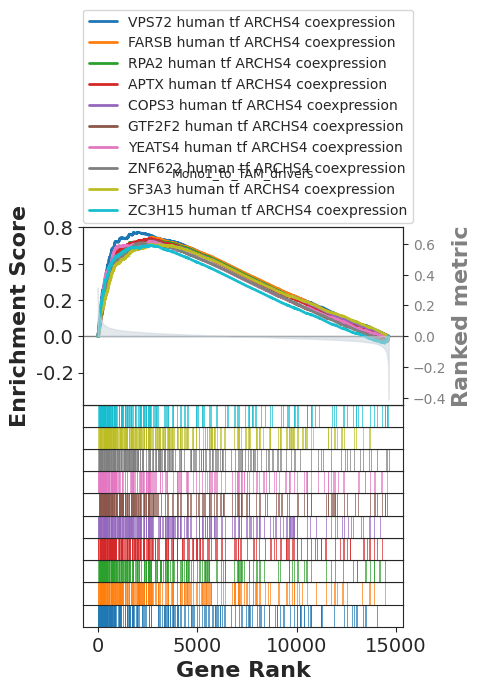

2026-06-26 16:46:55,124 [WARNING] Duplicated values found in preranked stats: 0.80% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Mono1_to_TAM_drivers: 1724 TFs (top: VPS72)


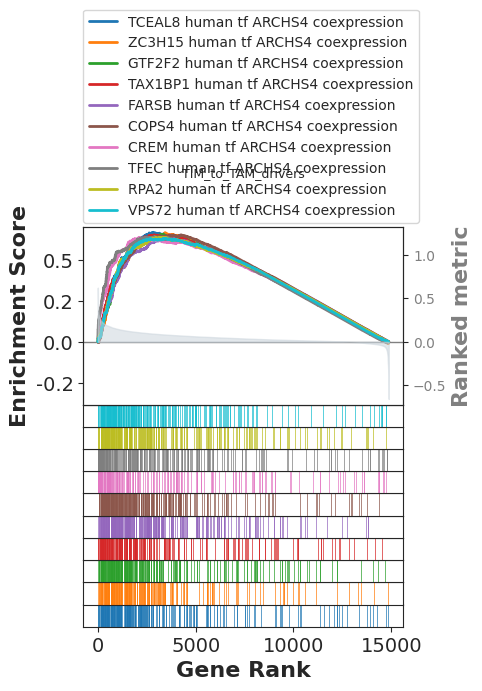

2026-06-26 16:47:02,156 [WARNING] Duplicated values found in preranked stats: 2.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


TIM_to_TAM_drivers: 1724 TFs (top: TCEAL8)


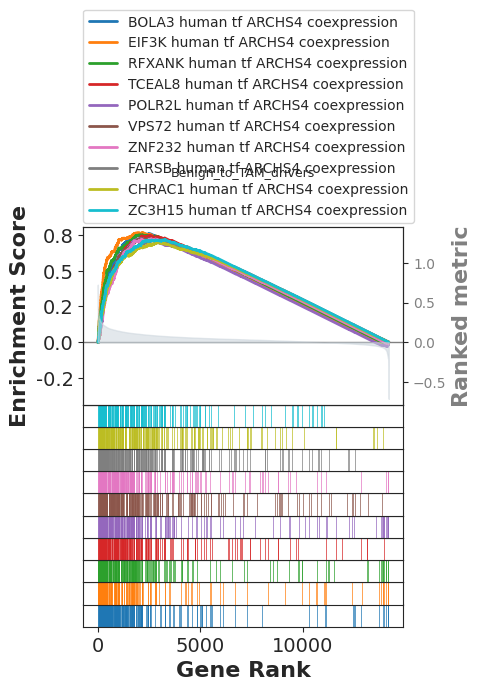

2026-06-26 16:47:08,171 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Benign_to_TAM_drivers: 1724 TFs (top: BOLA3)


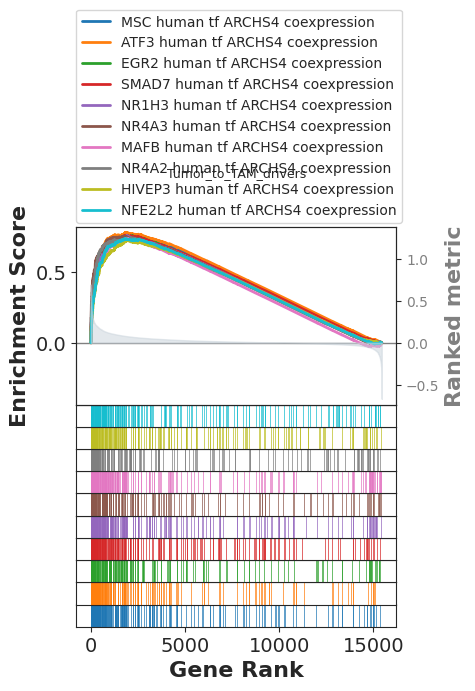

Tumor_to_TAM_drivers: 1724 TFs (top: MSC)
Done -> tf_enrichment_tables


In [147]:
import os
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt

# --- inputs: the ranked driver lists to find impacting TFs for ---
driver_dir = "driver_gene_tables"
input_files = [
    "Mono1_to_TAM_drivers.csv",
    "TIM_to_TAM_drivers.csv",
    "Benign_to_TAM_drivers.csv",
    "Tumor_to_TAM_drivers.csv",
]

TF_LIBRARY = "ARCHS4_TFs_Coexp"
out_dir = "tf_enrichment_tables"
os.makedirs(out_dir, exist_ok=True)

for fname in input_files:
    stem = fname.replace(".csv", "")

    # 1. load driver list -> ranking from the *_corr column
    df = pd.read_csv(os.path.join(driver_dir, fname)).dropna()
    df = df.rename(columns={df.columns[0]: "gene"})
    corr_col = [c for c in df.columns if c.endswith("_corr")][0]
    ranking = (df[["gene", corr_col]]
               .rename(columns={corr_col: "score"})
               .sort_values("score", ascending=False)
               .reset_index(drop=True))

    # 2. GSEA prerank against the TF library
    pre_res = gp.prerank(rnk=ranking, gene_sets=TF_LIBRARY,
                         seed=6, permutation_num=100, outdir=None, no_plot=True)

    # 3. results table, most-impacting TFs first (low FDR, high NES)
    rows = [[t, pre_res.results[t]['fdr'], pre_res.results[t]['nes'],
             pre_res.results[t]['es'], pre_res.results[t]['tag %'],
             pre_res.results[t]['gene %'], pre_res.results[t]['lead_genes']]
            for t in pre_res.results]
    out_df = (pd.DataFrame(rows, columns=['TF', 'fdr', 'nes', 'es', 'tag %', 'gene %', 'lead_genes'])
              .sort_values(['fdr', 'nes'], ascending=[True, False])
              .reset_index(drop=True))

    # 4a. SAVE the table
    out_df.to_csv(os.path.join(out_dir, f"ARCHS4_TFs_Coexps_{fname}"), index=False)

    # 4b. PRINT the enrichment plot of the top 10 TFs (not saved)
    top_terms = list(out_df['TF'][:10])
    pre_res.plot(top_terms, show_ranking=True, figsize=(4, 5))
    plt.suptitle(stem, y=1.02, fontsize=9)
    plt.show()

    print(f"{stem}: {len(out_df)} TFs (top: {out_df['TF'].iloc[0].split()[0]})")

print("Done ->", out_dir)